# 03. AutoIntent Few-Shot for Jailbreak Detection

Эксперименты AutoIntent в few-shot режиме на WildJailbreak.

## Содержание
1. Setup
2. Few-shot runs (n_shots × seeds)
3. Результаты — таблица из metrics.json
4. Scaling curve — F1 по n_shots
5. Variance analysis — std по seeds

## 1. Setup

In [1]:
# Load environment variables from .env (macOS ARM fix)
from dotenv import load_dotenv
load_dotenv("../../../.env")  # project root

import sys
import os
import subprocess
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
NOTEBOOK_DIR = Path.cwd()
TASK_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = TASK_DIR.parent.parent
SCRIPTS_DIR = TASK_DIR / "scripts"
PROCESSED = TASK_DIR / "data" / "processed"
RESULTS = TASK_DIR / "results"
RUNS = TASK_DIR / "runs"

sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir: {RESULTS}")
print(f"Runs dir: {RUNS}")
print(f"\nOMP_NUM_THREADS={os.environ.get('OMP_NUM_THREADS', 'not set')}")

Project root: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails
Results dir: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results
Runs dir: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs

OMP_NUM_THREADS=1


## 2. Few-shot runs

In [2]:
# Configuration
N_SHOTS_LIST = [10, 20, 50]
SEEDS = [42, 123, 456]

# Set to True to force retraining even if model exists
FORCE_RERUN = False

# Set to True to use small embedder (faster but not comparable)
PILOT_MODE = False

In [3]:
def get_model_dir(n_shots: int, seed: int, pilot: bool = False) -> Path:
    """Get model directory path."""
    model_name = "autointent_classic-light_pilot" if pilot else "autointent_classic-light"
    return RUNS / f"{model_name}_{n_shots}shot_seed{seed}"


def check_run_exists(n_shots: int, seed: int, pilot: bool = False) -> bool:
    """Check if run already completed (model dir exists with metadata)."""
    model_dir = get_model_dir(n_shots, seed, pilot)
    metadata_path = model_dir / "train_metadata.json"
    return metadata_path.exists()


def run_autointent(n_shots: int, seed: int, pilot: bool = False) -> int:
    """Run AutoIntent training and evaluation."""
    cmd = [
        sys.executable,
        str(SCRIPTS_DIR / "run_autointent.py"),
        "--mode", "fewshot",
        "--n_shots", str(n_shots),
        "--seed", str(seed),
    ]
    if pilot:
        cmd.append("--pilot")
    
    result = subprocess.run(cmd, cwd=str(TASK_DIR))
    return result.returncode

In [4]:
# Run all combinations
total_runs = len(N_SHOTS_LIST) * len(SEEDS)
completed = 0
skipped = 0
failed = 0

print(f"Total runs planned: {total_runs}")
print(f"FORCE_RERUN: {FORCE_RERUN}")
print(f"PILOT_MODE: {PILOT_MODE}")
print("=" * 60)

for n_shots in N_SHOTS_LIST:
    for seed in SEEDS:
        run_id = f"{n_shots}shot_seed{seed}"
        
        # Check if already exists
        if not FORCE_RERUN and check_run_exists(n_shots, seed, PILOT_MODE):
            print(f"[SKIP] {run_id} — already exists")
            skipped += 1
            continue
        
        print(f"\n[RUN] {run_id}")
        print("-" * 40)
        
        returncode = run_autointent(n_shots, seed, PILOT_MODE)
        
        if returncode == 0:
            print(f"[OK] {run_id} completed")
            completed += 1
        else:
            print(f"[FAIL] {run_id} failed with code {returncode}")
            failed += 1

print("\n" + "=" * 60)
print(f"Summary: completed={completed}, skipped={skipped}, failed={failed}")

Total runs planned: 9
FORCE_RERUN: False
PILOT_MODE: False
[SKIP] 10shot_seed42 — already exists
[SKIP] 10shot_seed123 — already exists

[RUN] 10shot_seed456
----------------------------------------
AutoIntent Training (Jailbreak Detection)
Mode: FINAL
Embedder: intfloat/multilingual-e5-large-instruct
Training: 10shot, seed=456
Output: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs/autointent_classic-light_10shot_seed456

Train: 20 samples
  - safe (label=0): 10
  - jailbreak (label=1): 10
Test: 2210 samples

Starting AutoML optimization...
This may take a while...



Filter: 100%|██████████| 13/13 [00:00<00:00, 6683.74 examples/s]
[I 2026-04-07 02:58:06,639] A new study created in RDB with name: NodeType.scoring
/Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition


AutoML optimization completed!
Saving model to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs/autointent_classic-light_10shot_seed456...

Training completed!

AutoIntent Evaluation (Jailbreak Detection)
Model: autointent_classic-light
Mode: 10shot
Embedder: intfloat/multilingual-e5-large-instruct

Loading model from /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs/autointent_classic-light_10shot_seed456...
Model loaded!

Test samples: 2210
  safe: 210, jailbreak: 2000

Running predictions...
Predictions: 2210
  predicted safe: 830
  predicted jailbreak: 1380

Computing metrics...

Results (10shot)
  f1: 0.7828
  precision: 0.9587
  recall: 0.6615
  over_refusal_rate: 0.2714
  recall_adversarial_harmful: 0.6615
Metrics saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/metrics.json
[OK] 1

Filter: 100%|██████████| 26/26 [00:00<00:00, 29641.72 examples/s]
[I 2026-04-07 02:58:50,877] A new study created in RDB with name: NodeType.scoring
/Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transitio


AutoML optimization completed!
Saving model to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs/autointent_classic-light_20shot_seed42...

Training completed!

AutoIntent Evaluation (Jailbreak Detection)
Model: autointent_classic-light
Mode: 20shot
Embedder: intfloat/multilingual-e5-large-instruct

Loading model from /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs/autointent_classic-light_20shot_seed42...
Model loaded!

Test samples: 2210
  safe: 210, jailbreak: 2000

Running predictions...
Predictions: 2210
  predicted safe: 404
  predicted jailbreak: 1806

Computing metrics...

Results (20shot)
  f1: 0.8671
  precision: 0.9136
  recall: 0.8250
  over_refusal_rate: 0.7429
  recall_adversarial_harmful: 0.8250
Metrics saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/metrics.json
[OK] 20s

...


AutoML optimization completed!
Saving model to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs/autointent_classic-light_50shot_seed42...

Training completed!

AutoIntent Evaluation (Jailbreak Detection)
Model: autointent_classic-light
Mode: 50shot
Embedder: intfloat/multilingual-e5-large-instruct

Loading model from /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs/autointent_classic-light_50shot_seed42...
Model loaded!

Test samples: 2210
  safe: 210, jailbreak: 2000

Running predictions...
Predictions: 2210
  predicted safe: 610
  predicted jailbreak: 1600

Computing metrics...

Results (50shot)
  f1: 0.8189
  precision: 0.9213
  recall: 0.7370
  over_refusal_rate: 0.6000
  recall_adversarial_harmful: 0.7370
Metrics saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/metrics.json
[OK] 50s

Filter: 100%|██████████| 66/66 [00:00<00:00, 50112.97 examples/s]
[I 2026-04-07 03:02:29,220] A new study created in RDB with name: NodeType.scoring
/Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transitio


AutoML optimization completed!
Saving model to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs/autointent_classic-light_50shot_seed123...

Training completed!

AutoIntent Evaluation (Jailbreak Detection)
Model: autointent_classic-light
Mode: 50shot
Embedder: intfloat/multilingual-e5-large-instruct

Loading model from /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs/autointent_classic-light_50shot_seed123...
Model loaded!

Test samples: 2210
  safe: 210, jailbreak: 2000

Running predictions...
Predictions: 2210
  predicted safe: 600
  predicted jailbreak: 1610

Computing metrics...

Results (50shot)
  f1: 0.8133
  precision: 0.9118
  recall: 0.7340
  over_refusal_rate: 0.6762
  recall_adversarial_harmful: 0.7340
Metrics saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/metrics.json
[OK] 5

Filter: 100%|██████████| 66/66 [00:00<00:00, 51083.98 examples/s]
[I 2026-04-07 03:03:36,411] A new study created in RDB with name: NodeType.scoring
/Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transitio


AutoML optimization completed!
Saving model to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs/autointent_classic-light_50shot_seed456...

Training completed!

AutoIntent Evaluation (Jailbreak Detection)
Model: autointent_classic-light
Mode: 50shot
Embedder: intfloat/multilingual-e5-large-instruct

Loading model from /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/runs/autointent_classic-light_50shot_seed456...
Model loaded!

Test samples: 2210
  safe: 210, jailbreak: 2000

Running predictions...
Predictions: 2210
  predicted safe: 1379
  predicted jailbreak: 831

Computing metrics...

Results (50shot)
  f1: 0.5602
  precision: 0.9543
  recall: 0.3965
  over_refusal_rate: 0.1810
  recall_adversarial_harmful: 0.3965
Metrics saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/metrics.json
[OK] 5

## 3. Результаты — таблица из metrics.json

In [5]:
# Load results
metrics_path = RESULTS / "metrics.json"

if metrics_path.exists():
    with open(metrics_path, "r") as f:
        all_results = json.load(f)
    
    # Handle both list and dict formats
    if isinstance(all_results, dict):
        all_results = list(all_results.values())
    
    # Filter AutoIntent results
    ai_results = [r for r in all_results if "autointent" in r.get("model_name", "").lower()]
    
    if ai_results:
        df = pd.DataFrame(ai_results)
        
        # Select and order columns
        cols = ["n_shots", "seed", "f1", "precision", "recall", 
                "over_refusal_rate", "recall_adversarial_harmful"]
        cols = [c for c in cols if c in df.columns]
        
        df_display = df[cols].sort_values(["n_shots", "seed"])
        
        print(f"AutoIntent results: {len(df_display)} runs")
        display(df_display)
    else:
        print("No AutoIntent results found in metrics.json")
else:
    print(f"No results file found at {metrics_path}")
    print("Run the training first (section 2).")

AutoIntent results: 9 runs


,n_shots,seed,f1,precision,recall,over_refusal_rate,recall_adversarial_harmful
0,10,42,0.757155,0.873774,0.6680,0.919048,0.6680
1,10,123,0.730663,0.940205,0.5975,0.361905,0.5975
2,10,456,0.782840,0.958696,0.6615,0.271429,0.6615
3,20,42,0.867052,0.913621,0.8250,0.742857,0.8250
4,20,123,0.749701,0.934328,0.6260,0.419048,0.6260
5,20,456,0.771327,0.946221,0.6510,0.352381,0.6510
6,50,42,0.818889,0.921250,0.7370,0.600000,0.7370
7,50,123,0.813296,0.911801,0.7340,0.676190,0.7340
8,50,456,0.560226,0.954272,0.3965,0.180952,0.3965


## 4. Scaling Curve — F1 по n_shots

In [6]:
# Aggregate by n_shots (mean ± std across seeds)
if metrics_path.exists() and 'df' in dir() and len(df) > 0:
    scaling_data = []
    
    for n_shots in N_SHOTS_LIST:
        subset = df[df["n_shots"] == n_shots]
        if len(subset) > 0:
            scaling_data.append({
                "n_shots": n_shots,
                "f1_mean": subset["f1"].mean(),
                "f1_std": subset["f1"].std() if len(subset) > 1 else 0,
                "recall_mean": subset["recall"].mean(),
                "recall_std": subset["recall"].std() if len(subset) > 1 else 0,
                "n_seeds": len(subset),
            })
    
    scaling_df = pd.DataFrame(scaling_data)
    
    print("AutoIntent: F1 и Recall по n_shots (mean ± std)")
    print("=" * 60)
    for _, row in scaling_df.iterrows():
        f1_str = f"{row['f1_mean']:.3f} ± {row['f1_std']:.3f}" if row['f1_std'] > 0 else f"{row['f1_mean']:.3f}"
        recall_str = f"{row['recall_mean']:.3f} ± {row['recall_std']:.3f}" if row['recall_std'] > 0 else f"{row['recall_mean']:.3f}"
        print(f"  {int(row['n_shots']):>2}-shot: F1 = {f1_str}, Recall = {recall_str} ({int(row['n_seeds'])} seeds)")
else:
    print("No data available for scaling curve")

AutoIntent: F1 и Recall по n_shots (mean ± std)
  10-shot: F1 = 0.757 ± 0.026, Recall = 0.642 ± 0.039 (3 seeds)
  20-shot: F1 = 0.796 ± 0.062, Recall = 0.701 ± 0.108 (3 seeds)
  50-shot: F1 = 0.731 ± 0.148, Recall = 0.623 ± 0.196 (3 seeds)


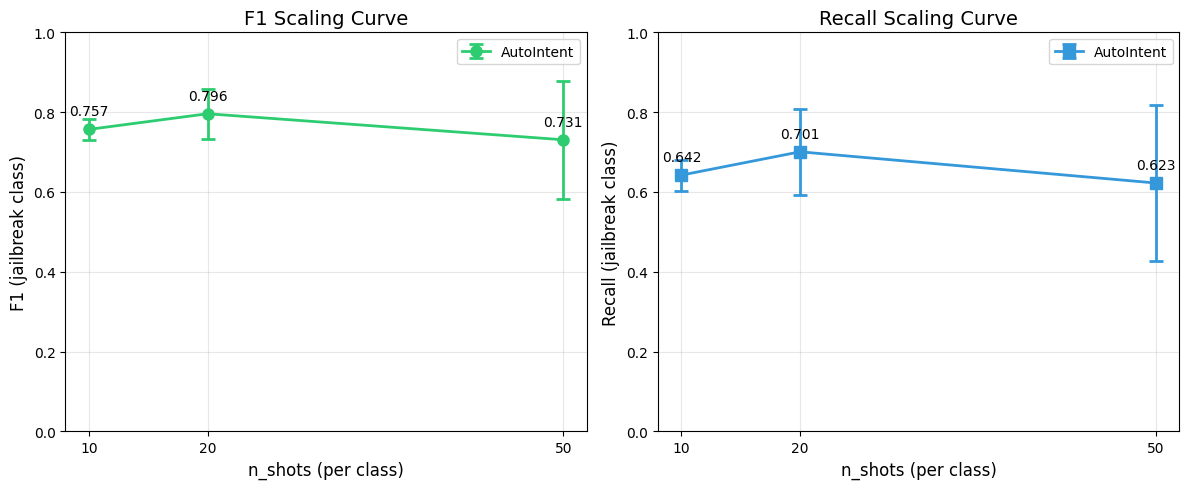

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/scaling_curve_fewshot.png


In [7]:
# Plot scaling curve
if 'scaling_df' in dir() and len(scaling_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # F1 plot
    ax = axes[0]
    x = scaling_df["n_shots"]
    ax.errorbar(x, scaling_df["f1_mean"], yerr=scaling_df["f1_std"], 
                fmt='o-', capsize=5, capthick=2, markersize=8, linewidth=2,
                color='#2ecc71', label='AutoIntent')
    
    # Add value labels
    for i, row in scaling_df.iterrows():
        ax.annotate(f"{row['f1_mean']:.3f}", 
                    (row['n_shots'], row['f1_mean']),
                    textcoords="offset points", xytext=(0, 10),
                    ha='center', fontsize=10)
    
    ax.set_xlabel("n_shots (per class)", fontsize=12)
    ax.set_ylabel("F1 (jailbreak class)", fontsize=12)
    ax.set_title("F1 Scaling Curve", fontsize=14)
    ax.set_xticks(N_SHOTS_LIST)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Recall plot
    ax = axes[1]
    ax.errorbar(x, scaling_df["recall_mean"], yerr=scaling_df["recall_std"],
                fmt='s-', capsize=5, capthick=2, markersize=8, linewidth=2,
                color='#3498db', label='AutoIntent')
    
    for i, row in scaling_df.iterrows():
        ax.annotate(f"{row['recall_mean']:.3f}",
                    (row['n_shots'], row['recall_mean']),
                    textcoords="offset points", xytext=(0, 10),
                    ha='center', fontsize=10)
    
    ax.set_xlabel("n_shots (per class)", fontsize=12)
    ax.set_ylabel("Recall (jailbreak class)", fontsize=12)
    ax.set_title("Recall Scaling Curve", fontsize=14)
    ax.set_xticks(N_SHOTS_LIST)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(RESULTS / "scaling_curve_fewshot.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {RESULTS / 'scaling_curve_fewshot.png'}")
else:
    print("No data available for plotting")

## 5. Variance Analysis — std по seeds

In [8]:
# Variance analysis
if 'scaling_df' in dir() and len(scaling_df) > 0:
    print("Variance Analysis (CV = std/mean)")
    print("=" * 60)
    
    for _, row in scaling_df.iterrows():
        cv_f1 = row['f1_std'] / row['f1_mean'] * 100 if row['f1_mean'] > 0 else 0
        cv_recall = row['recall_std'] / row['recall_mean'] * 100 if row['recall_mean'] > 0 else 0
        
        print(f"\n{int(row['n_shots'])}-shot ({int(row['n_seeds'])} seeds):")
        print(f"  F1:     {row['f1_mean']:.3f} ± {row['f1_std']:.3f}  (CV = {cv_f1:.1f}%)")
        print(f"  Recall: {row['recall_mean']:.3f} ± {row['recall_std']:.3f}  (CV = {cv_recall:.1f}%)")
    
    # Overall stability
    avg_cv = scaling_df['f1_std'].mean() / scaling_df['f1_mean'].mean() * 100
    print(f"\nOverall F1 CV: {avg_cv:.1f}%")
    
    if avg_cv < 5:
        print("Verdict: STABLE (CV < 5%)")
    elif avg_cv < 10:
        print("Verdict: MODERATE (CV 5-10%)")
    else:
        print("Verdict: UNSTABLE (CV > 10%)")
else:
    print("No data available for variance analysis")

Variance Analysis (CV = std/mean)

10-shot (3 seeds):
  F1:     0.757 ± 0.026  (CV = 3.4%)
  Recall: 0.642 ± 0.039  (CV = 6.1%)

20-shot (3 seeds):
  F1:     0.796 ± 0.062  (CV = 7.8%)
  Recall: 0.701 ± 0.108  (CV = 15.5%)

50-shot (3 seeds):
  F1:     0.731 ± 0.148  (CV = 20.2%)
  Recall: 0.623 ± 0.196  (CV = 31.4%)

Overall F1 CV: 10.3%
Verdict: UNSTABLE (CV > 10%)


In [9]:
# Detailed per-seed results
if 'df' in dir() and len(df) > 0:
    print("\nDetailed results per seed:")
    print("=" * 60)
    
    pivot = df.pivot_table(
        index='n_shots', 
        columns='seed', 
        values='f1',
        aggfunc='first'
    )
    
    if not pivot.empty:
        # Add mean and std columns
        pivot['mean'] = pivot.mean(axis=1)
        pivot['std'] = pivot.std(axis=1)
        
        display(pivot.round(3))


Detailed results per seed:


seed,42,123,456,mean,std
n_shots,,,,,
10,0.757,0.731,0.783,0.757,0.021
20,0.867,0.750,0.771,0.796,0.051
50,0.819,0.813,0.560,0.731,0.121


## Выводы

**Модель:** AutoIntent classic-light, embedder: intfloat/multilingual-e5-large-instruct
**Протокол:** n_shots ∈ [10, 20, 50], seeds ∈ [42, 123, 456], 9 runs

### Результаты (mean ± std)

| n_shots | F1 | Recall | CV(F1) |
|---------|----|--------|--------|
| 10-shot | 0.757 ± 0.026 | 0.642 ± 0.039 | 3.4% |
| 20-shot | 0.796 ± 0.062 | 0.701 ± 0.108 | 7.8% |
| 50-shot | 0.731 ± 0.148 | 0.623 ± 0.196 | 20.2% |

Вердикт variance: **UNSTABLE** (overall CV = 10.5% > 10%)

### Ключевые наблюдения

1. **Задача решается.** F1=0.757–0.796 при 20–40 обучающих примерах
   на полностью adversarial тесте — нетривиальный результат.

2. **20-shot — оптимальная точка.** Скейлинг немонотонен: 50-shot
   хуже 20-shot по среднему — та же аномалия, что в OOS-спринте.

3. **Катастрофическая нестабильность на 50-shot.** CV=20.2%.
   Причина: seed=456 даёт F1=0.560 (recall=0.397) — деградация
   порога, аналогичная OOS 50-shot провалу. Два других seed: ~0.815.

4. **Over-refusal rate тревожный.** Лучший run (20-shot seed=42,
   F1=0.867) блокирует 74.3% безопасных промптов. Precision высокая
   (0.91–0.96 везде), но ценой агрессивного блокирования safe-класса.

5. **Сравнение с OOS-спринтом.** 20-shot F1=0.796 vs OOS 20-shot
   F1=0.819 при сопоставимой variance — adversarial природа данных
   не приводит к значительной деградации качества.